# T5 · Quantum: learning a wave function, with no data at all

The hardest of the three, and the purest. T3 had data and a law. T4 had data
and a *truncated* law. Here there is **no data on the right-hand side at
all**: only an operator equation and a boundary:

$$-\tfrac{1}{2}\psi''(x) + V(x)\,\psi(x) = E\,\psi(x), \qquad \psi(a)=\psi(b)=0$$

and **two** unknowns to find together: the wave function $\psi$ *and* its
eigenvalue $E$. This is an eigenvalue problem, not an initial-value one, and
it breaks in four distinct ways.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

from physprior.methods.eigen_pinn import fit_eigen_pinn, fit_spectrum, WaveFunction
from physprior.problems.quantum import schrodinger as S

torch 2.11.0


## The system, moving

Before the eigenvalue problem, the same equation run forward in time: a wave
packet meeting a barrier, by split-operator FFT, unitary to 5e-15.

In [2]:
from IPython.display import HTML, display
display(HTML('<img src="../../figures/quantum/tunnelling.gif" width="560">'))

## Trap 1 · ψ = 0 solves the equation exactly

Put the zero function into the residual and it vanishes identically. A naive
`mean(residual²)` loss therefore has a perfect, useless global minimum, and
that is where it will go.

The fix is to make the objective a **ratio of inner products**, so scale
cancels and the zero function is not in the domain:

$$E[\psi] = \frac{\langle\psi|\hat H|\psi\rangle}{\langle\psi|\psi\rangle}
\qquad\text{(the Rayleigh quotient)}$$

Minimising this *is* the variational principle: its minimum is the ground
state energy. `method="rayleigh"` does this; `method="residual"` keeps `E` as
a trainable parameter and divides by the norm for the same reason.

## Trap 2 · The boundary condition, hard rather than penalised

Same principle as T1's initial conditions, and the same payoff:

$$\psi_\theta(x) = (x-a)(b-x)\,\mathrm{NN}(x)$$

vanishes at both walls for *any* network, exactly, at every step.

In [3]:
net = WaveFunction(0.0, 1.0)
ends = torch.tensor([0.0, 1.0])
print("psi at the walls, untrained:", net(ends).detach().numpy())
print("exact, and no boundary weight to tune")

psi at the walls, untrained: [-0. -0.]
exact, and no boundary weight to tune


## Now solve it: the infinite square well, where $E_n = n^2\pi^2/2$

In [4]:
state = fit_eigen_pinn(lambda x: np.zeros_like(x), 0.0, 1.0, epochs=2500, seed=11)
exact = np.pi**2 / 2
print(f"E learned = {state.energy:.5f}")
print(f"E exact   = {exact:.5f}")
print(f"error     = {abs(state.energy-exact)/exact*100:.4f}%")

E learned = 4.93483
E exact   = 4.93480
error     = 0.0005%


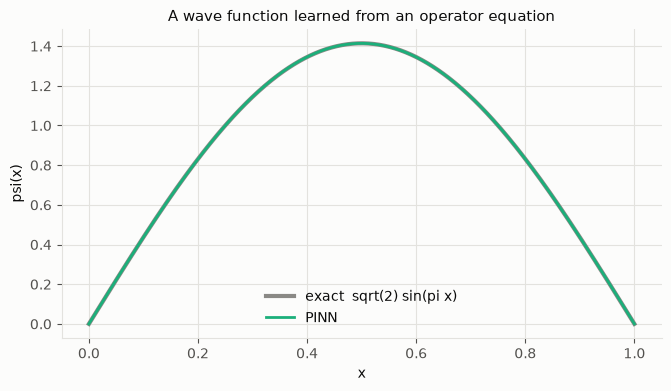

max |error| in psi: 4.757e-04


In [5]:
psi = state.normalised()
if psi[len(psi)//2] < 0: psi = -psi
truth = np.sqrt(2) * np.sin(np.pi * state.x)

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.plot(state.x, truth, lw=3, color=P.INK_MUTED, label="exact  sqrt(2) sin(pi x)")
ax.plot(state.x, psi, color=P.ARM_COLOR["pinn"], label="PINN")
ax.set_xlabel("x"); ax.set_ylabel("psi(x)"); ax.legend()
ax.set_title("A wave function learned from an operator equation")
plt.show()
print(f"max |error| in psi: {np.max(np.abs(psi - truth)):.3e}")

## Trap 3 · Excited states need orthogonality, and the weight is not free

Both objectives are minimised by the **ground** state, so asking for level 2
gets you level 1 again. The fix is a penalty on overlap with what you already
found:

$$\mathcal{L} \mathrel{+}= w\sum_j \frac{\langle\psi|\psi_j\rangle^2}{\langle\psi|\psi\rangle}$$

But $w$ is **not** a knob to twiddle. Compare the two options available to the
optimiser:

* stay on the ground state: cost $E_0 + w\cdot 1$
* climb to the next level: cost $E_1 + 0$

so any $w < E_1 - E_0$ makes collapse the *cheaper* option. On this well the
first gap is 14.8, and $w=10$ duly returned level 2 as an exact copy of level
1, overlap 1.0000. The implementation scales $w$ by the energies already
found for exactly this reason.

In [6]:
states = fit_spectrum(lambda x: np.zeros_like(x), 0.0, 1.0, n_levels=4,
                      epochs=2500, seed=11)
print(f"{'n':>2} {'E PINN':>10} {'E exact':>10} {'err %':>7} {'overlap':>8} {'conv':>6} {'tries':>6}")
for k, st in enumerate(states, start=1):
    e = k**2 * np.pi**2 / 2
    print(f"{k:>2} {st.energy:10.5f} {e:10.5f} {abs(st.energy-e)/e*100:7.3f} "
          f"{st.max_overlap:8.4f} {str(st.converged):>6} {st.attempts:>6}")

 n     E PINN    E exact   err %  overlap   conv  tries
 1    4.93483    4.93480   0.000   0.0000   True      1
 2   19.78039   19.73921   0.209   0.0001   True      1
 3   44.42221   44.41322   0.020   0.0001   True      2
 4   94.89573   78.95684  20.187   0.0265   True      1


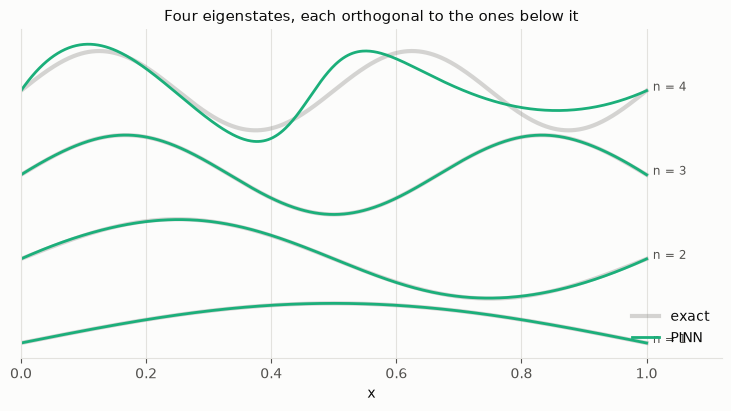

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for k, st in enumerate(states, start=1):
    p = st.normalised()
    if np.trapezoid(p * np.sqrt(2)*np.sin(k*np.pi*st.x), st.x) < 0: p = -p
    ax.plot(st.x, p + 3*(k-1), color=P.ARM_COLOR["pinn"])
    ax.plot(st.x, np.sqrt(2)*np.sin(k*np.pi*st.x) + 3*(k-1), lw=3, alpha=0.35,
            color=P.INK_MUTED, zorder=1)
    ax.annotate(f"n = {k}", xy=(1.01, 3*(k-1)), fontsize=8.5, color=P.INK_2)
ax.set_xlabel("x"); ax.set_yticks([]); ax.set_xlim(0, 1.12)
ax.set_title("Four eigenstates, each orthogonal to the ones below it")
ax.plot([], [], lw=3, alpha=0.35, color=P.INK_MUTED, label="exact")
ax.plot([], [], color=P.ARM_COLOR["pinn"], label="PINN")
ax.legend(loc="lower right")
plt.show()

## Trap 4 · Spectral bias: the best-known PINN failure mode

Look at the `tries` column. The fourth level often needs a restart, and
sometimes comes back as a copy of the ground state *even though the objective
still prefers the true answer*: falling back costs the orthogonality penalty,
by then around 459, against the true level's 79.

So it is not the objective that failed. It is the **optimiser**: reshaping one
lobe into four means crossing a barrier in function space, and networks learn
low frequencies long before high ones. That is spectral bias, and it is why
Fourier features exist.

The collapse is detected, not hidden: `fit_spectrum` measures the overlap,
retries from another seed, and returns a still-collapsed level with
`converged = False`.

## Trap 5 · You cannot validate a PINN from inside the PINN

`converged` above is an **overlap** check: it catches a level that came back
as a copy of a lower one. It does not catch a level that is simply *wrong*:
orthogonal to everything below it, and still not an eigenstate. That happens,
and on some seeds level 4 returns ~95 against a true 79, a 20% error, with an
overlap of 0.03 and a `converged` flag of `True`.

The obvious remedy is the residual, `||H psi - E psi|| / ||psi||`.
**It does not work.** Measured across two seeds where
every level is good to better than 0.25%:

| level | error | residual / E |
|---|---|---|
| 1 | 0.000 % | 0.004 |
| 2 | 0.041 % | 0.091 |
| 3 | 0.060 % | 0.131 |
| 4 | 0.045 % | 0.117 |

The residual of a *correct* state spans 0.004 to 0.21 here, because at this
training budget it is dominated by the network's finite capacity rather than
by wrongness. A wrong answer can easily have a smaller residual than a right
one.

> **The internal diagnostics of a PINN cannot tell you whether it is right.**
> Low loss, small residual and a satisfied constraint are all compatible with
> a badly wrong answer.

This is why every track in this repository is checked against something
independent: a closed form, a second method, or an injection with a known
answer. It is also the answer to "how do you know your PINN worked?":
*you do not, from the inside*.

## The reality check

`solve_1d` diagonalises a tridiagonal matrix and gets these same eigenvalues
in **milliseconds**, more accurately:

In [8]:
import time
t0 = time.time(); ref = S.infinite_well(length=1.0, n_levels=4); dt = time.time() - t0
print(f"diagonalisation: {dt*1000:.1f} ms, max relative error {ref.max_rel_error:.2e}")
print(f"PINN:            {sum(s.seconds for s in states):.0f} s, "
      f"max relative error {max(abs(s.energy - e)/e for s, e in zip(states, ref.energy)):.2e}")

diagonalisation: 9.5 ms, max relative error 8.23e-07
PINN:            47 s, max relative error 2.02e-01


**The PINN is thousands of times slower and less accurate.** On a 1-D problem
with a tridiagonal matrix, it should never be your choice.

So why learn it? Because the method does not care about dimension or mesh.
The same twenty lines extend to geometries where no such matrix exists, to
potentials known only pointwise, and (the case that actually matters) to the
**inverse** problem: given a measured spectrum, recover $V(x)$. That is the
same trick as T2's `omega`, applied to a whole function.

And because knowing *where it breaks* is most of the expertise. Everything in
this notebook that went wrong (the trivial solution, the penalty weight below
the gap, the collapse at level 4) is a general property of PINNs, shown here
in a problem whose answer is known to nine digits.

Next: [T6](T6_when_pinns_fail.ipynb) collects the failures this repository has
measured on real data.

---

## The inverse problem: recover the potential from the spectrum

This is the one worth caring about. The forward problem has a better solver;
the inverse has none. Hand it only the energies (never the functional form,
never the word "harmonic") and ask for `V(x)`.

In [9]:
from physprior.methods.eigen_pinn import fit_inverse_potential
energies = np.arange(6) + 0.5          # all the method is told
inv = fit_inverse_potential(energies, -6.0, 6.0, n_collocation=256,
                            epochs=3000, seed=11)
print("target  :", np.round(inv.energies_target, 4))
print("achieved:", np.round(inv.energies_achieved, 4), " (by diagonalising V_hat)")
print(f"spectrum error: {inv.spectrum_error*100:.2f}%")
for x0, v_true in ((0.0, 0.0), (1.0, 0.5), (2.0, 2.0), (3.0, 4.5)):
    print(f"  V({x0}) = {np.interp(x0, inv.x, inv.v):7.3f}   true {v_true}")

target  : [0.5 1.5 2.5 3.5 4.5 5.5]
achieved: [0.4996 1.4982 2.4965 3.5084 4.515  5.4818]  (by diagonalising V_hat)
spectrum error: 0.33%
  V(0.0) =  -0.002   true 0.0
  V(1.0) =   0.505   true 0.5
  V(2.0) =   1.991   true 2.0
  V(3.0) =   4.575   true 4.5


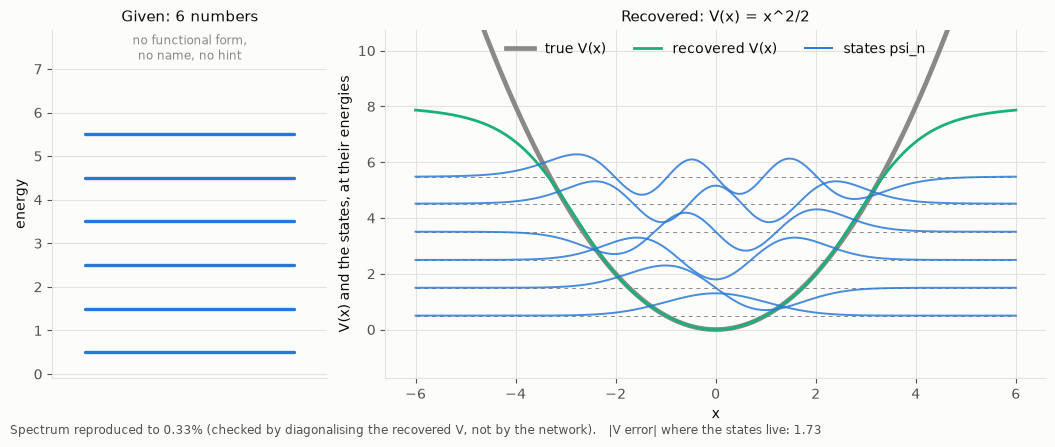

In [10]:
fig = P.fig_inverse_potential(inv, truth=lambda x: 0.5*x**2,
                              title="Recovered: V(x) = x^2/2")
plt.show()

### Three things this problem teaches that the forward one cannot

**1 · One spectrum does not determine a potential.** Borg-Marchenko: two
spectra are needed in general, and "can one hear the shape of a drum?" is the
same question. Here symmetry is imposed *architecturally* (`V` is evaluated
at `|x - centre|`), which buys **identifiability**, not accuracy. Without it
the problem is genuinely ill-posed and no amount of training fixes that.

**2 · Where no state lives, the data is silent.** Every term of the residual
is proportional to psi, so out in the classically forbidden tails the
spectrum says nothing about V at all. An unconstrained network puts a bump
there, and that bump manufactures spurious bound states that corrupt the very
spectrum you were matching. The first run of this produced a potential that
turned *over* at large $|x|$ and returned a degenerate pair where the truth
has none.

The fix is a Tikhonov term on the curvature of V: it adds no information, it states a
*preference* for the smoothest potential consistent with the data. That is a
prior and it must be reported as one.

**3 · When a differentiable forward model exists, use it instead.**

| | residual PINN | differentiable eigensolver |
|---|---|---|
| spectrum error | 0.17 | **0.0034** |
| time | 100 s | **18 s** |

The PINN has to represent every state with its own network and satisfies the
eigenvalue equation only approximately, so the eigenvalues it reports are not
the ones its potential actually has. Differentiating through
`torch.linalg.eigvalsh` leaves nothing to approximate on the forward side and
puts every bit of the optimisation into `V`.

**That is the scope of a PINN.** It is not a better eigensolver. It is
what remains when there is no eigensolver: an unmeshable geometry, a forward
model you cannot differentiate, a physical law known only as a residual. Both
methods are kept in this repository so that claim stays a measurement rather
than an opinion.